# Project: Wholesale Customer Segmentation using Hierarchical Clustering
### Step 1: Project Overview and Setup
### Objectives:
* **Problem:** Group 440 wholesale customers based on their annual spending behavior.
* **Goal:** Use Unsupervised Learning to find natural business categories (e.g., Hotels vs. Retailers).
* **Constraints:** Implement a structured preprocessing pipeline and evaluate using the Silhouette Score.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

df = pd.read_csv('/content/archive (4).zip')
print(f"Dataset Loaded: {df.shape[0]} customers found.")
df.head()

Dataset Loaded: 440 customers found.


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### Step 2: The Preprocessing Pipeline
We build a reusable function to clean the data.
1. **Feature Selection:** We remove 'Channel' and 'Region' because they are labels, not spending behavior.
2. **Normalization:** We use a Log Transform to handle "skewed" data (where a few big spenders distort the average).
3. **Scaling:** We use StandardScaler so that 'Milk' and 'Fresh' are compared on the same scale.

In [14]:
def my_preprocessing_pipeline(data):

    X = data.drop(['Channel', 'Region'], axis=1)

    X_log = np.log1p(X)


    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_log)

    return X_scaled, scaler

X_final, fitted_scaler = my_preprocessing_pipeline(df)
print("✓ Pipeline successfully transformed the messy data.")

✓ Pipeline successfully transformed the messy data.


### Step 3: Exploratory Data Analysis
Before clustering, we check for correlations. If 'Grocery' and 'Detergents' are highly correlated, it confirms that certain businesses buy specific "bundles" of products.

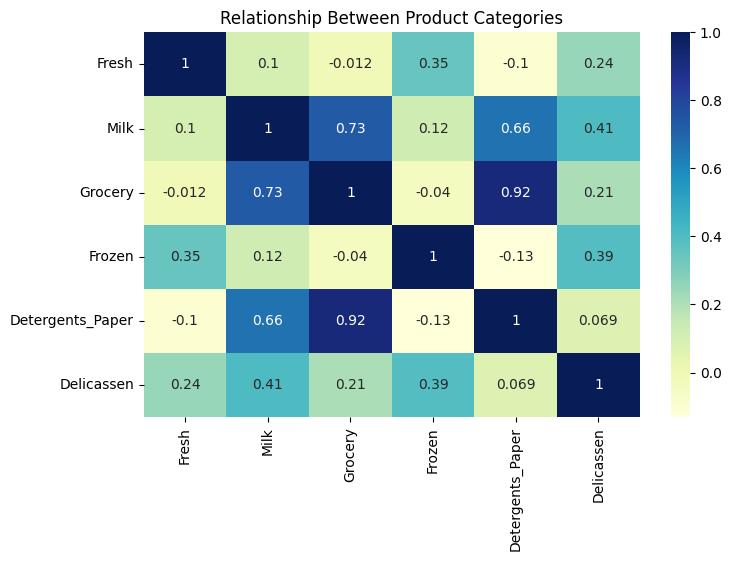

In [15]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.drop(['Channel', 'Region'], axis=1).corr(), annot=True, cmap='YlGnBu')
plt.title("Relationship Between Product Categories")
plt.show()

### Step 4: Finding the Optimal Clusters (The 'Tree' Analysis)
In Hierarchical Clustering, we don't guess the number of clusters. We use a **Dendrogram**.
The vertical lines represent the distance between clusters. We look for the "tallest" vertical line to decide where to 'cut' the tree.

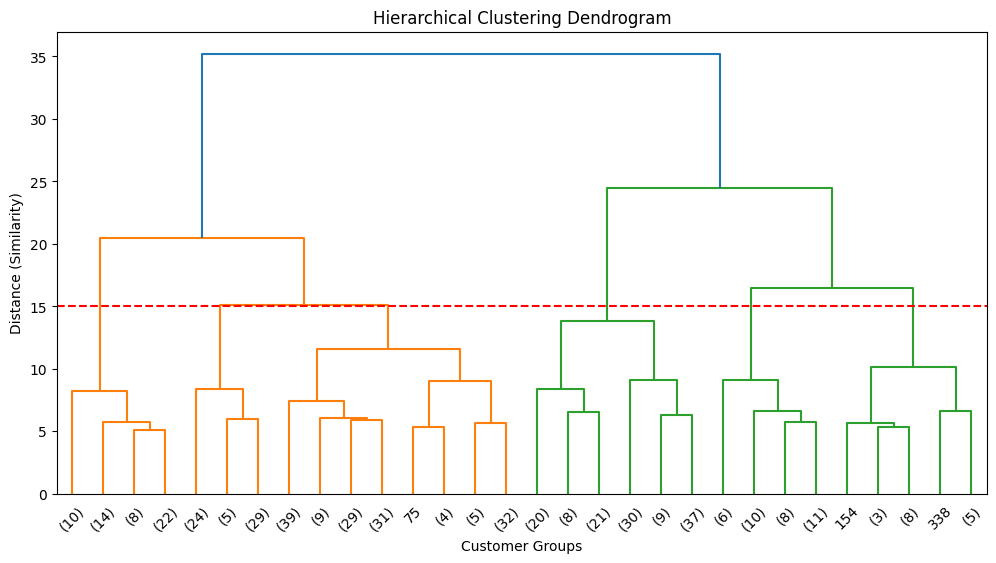

Choosing k=3 clusters based on the visual hierarchy.


In [16]:
Z = linkage(X_final, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.axhline(y=15, color='red', linestyle='--')
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups")
plt.ylabel("Distance (Similarity)")
plt.show()

print("Choosing k=3 clusters based on the visual hierarchy.")

### Step 5: Training & Evaluating the Model
We apply the **Agglomerative Clustering** algorithm. Since we don't have 'correct' answers, we use the **Silhouette Score** to see how well-separated our groups are.

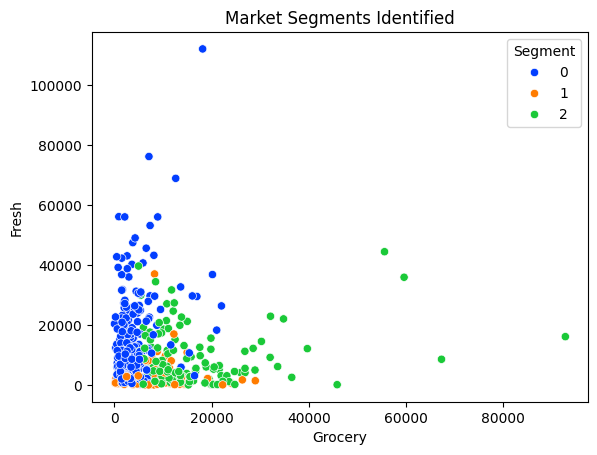

Model Performance (Silhouette Score): 0.2547

Average Spending per Segment:
         Channel  Region     Fresh      Milk   Grocery   Frozen  \
Segment                                                           
0           1.04    2.51  15016.10   3389.94   3673.95  4187.85   
1           1.49    2.64   3913.96   5222.98   8657.92  1198.42   
2           1.84    2.58   9107.78  11083.01  16616.93  1527.34   

         Detergents_Paper  Delicassen  
Segment                                
0                  616.81     1552.75  
1                 3474.11      190.49  
2                 7377.01     2032.21  


In [17]:
cluster_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Segment'] = cluster_model.fit_predict(X_final)

# Here is your scatter plot
sns.scatterplot(data=df, x='Grocery', y='Fresh', hue='Segment', palette='bright')
plt.title(f"Market Segments Identified")
plt.show()
score = silhouette_score(X_final, df['Segment'])
print(f"Model Performance (Silhouette Score): {score:.4f}")

print("\nAverage Spending per Segment:")
print(df.groupby('Segment').mean(numeric_only=True).round(2))

### Step 6: Model Persistence
We save the model and the scaler into a `.pkl` file. This allows us to use this exact logic on new customer data in the future without retraining.

In [18]:
project_files = {
    'scaler': fitted_scaler,
    'model': cluster_model
}

joblib.dump(project_files, 'wholesale_ai_project.pkl')
print("✓ File 'wholesale_ai_project.pkl' is ready for download.")

✓ File 'wholesale_ai_project.pkl' is ready for download.
